<a href="https://colab.research.google.com/github/ntqn23521128/PTDLKD_IS403.Q11/blob/main/Nhom2_Bank_Churn_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# ============================================================
# 1) Import thư viện
# ============================================================
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split

# ============================================================

In [ ]:
# 2) Đọc dữ liệu
# ============================================================
df = pd.read_csv("Churn_Modelling.csv")
print("Dữ liệu ban đầu:")
display(df.head())

# ============================================================

Dữ liệu ban đầu:


,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [ ]:
# 3) Khám phá dữ liệu
# ============================================================
print(df.info())
print(df.describe())
print("Số lượng giá trị null mỗi cột:")
print(df.isnull().sum())

# ============================================================

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB
None
         RowNumber    CustomerId   CreditScore           Age        Tenure  \
count  1000

In [ ]:
# 4) Tiền xử lý dữ liệu
# ============================================================

# Bước 4.1 – Xóa các cột không cần thiết
df = df.drop(['RowNumber', 'CustomerId', 'Surname'], axis=1)

# Bước 4.2 – Mã hóa giới tính
le = LabelEncoder()
df['Gender'] = le.fit_transform(df['Gender'])   # Male=1, Female=0

# Bước 4.3 – One-Hot Encoding cho Geography (quan trọng)
df = pd.get_dummies(df, columns=['Geography'], drop_first=True)

# Bước 4.4 – Chuẩn hóa các cột số
cols_to_scale = ['CreditScore', 'Age', 'Tenure', 'Balance',
                 'NumOfProducts', 'EstimatedSalary']

scaler = StandardScaler()
df[cols_to_scale] = scaler.fit_transform(df[cols_to_scale])

# Bước 4.5 – Tách X và y
X = df.drop('Exited', axis=1)
y = df['Exited']

# ============================================================

In [ ]:
# 5) Chia dữ liệu Train/Test (80/20 + stratify)
# ============================================================
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# ============================================================

In [ ]:
# 6) Thông tin sau tiền xử lý
# ============================================================
print("Hoàn tất tiền xử lý!")
print("Kích thước tập huấn luyện:", X_train.shape)
print("Kích thước tập kiểm tra:", X_test.shape)
print("Tỷ lệ churn trong tập train:", y_train.mean())
print("Tỷ lệ churn trong tập test:", y_test.mean())

print("\nCác cột sau tiền xử lý:")
print(X_train.columns)

Hoàn tất tiền xử lý!
Kích thước tập huấn luyện: (8000, 11)
Kích thước tập kiểm tra: (2000, 11)
Tỷ lệ churn trong tập train: 0.20375
Tỷ lệ churn trong tập test: 0.2035

Các cột sau tiền xử lý:
Index(['CreditScore', 'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts',
       'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'Geography_Germany',
       'Geography_Spain'],
      dtype='object')



📌 BƯỚC 1: KIỂM TRA ĐA CỘNG TUYẾN (VIF)
              Feature       VIF
6           HasCrCard  2.199459
1              Gender  1.840025
7      IsActiveMember  1.766546
9   Geography_Germany  1.576536
10    Geography_Spain  1.353327
4             Balance  1.323142
5       NumOfProducts  1.124344
2                 Age  1.011604
3              Tenure  1.002327
8     EstimatedSalary  1.001345
0         CreditScore  1.001028

📌 BƯỚC 2: TỐI ƯU HÓA MÔ HÌNH (GRID SEARCH)
Fitting 5 folds for each of 5 candidates, totalling 25 fits

✅ Tham số tốt nhất (Best C): 0.01
✅ AUC trung bình trên tập Train (CV): 0.7676

📌 BƯỚC 3: TỐI ƯU NGƯỠNG (THRESHOLD TUNING)
✅ Ngưỡng tối ưu (Best Threshold): 0.5654
   (Nghĩa là xác suất >= 56.5% thì mới tính là Rời bỏ)

📌 BƯỚC 4: KẾT QUẢ ĐÁNH GIÁ CUỐI CÙNG
 KIỂM TRA OVERFITTING:
   - Train Accuracy: 0.7174
   - Test Accuracy : 0.7680
   ✅ TỐT: Mô hình ổn định, không bị học vẹt.

 CHỈ SỐ TRÊN TẬP TEST:
    AUC Score : 0.7780  (Quan trọng nhất)
    Recall    : 0.6069  

/tmp/ipython-input-2402326591.py:76: RuntimeWarning: invalid value encountered in divide
  f1_scores = 2 * (precisions * recalls) / (precisions + recalls)


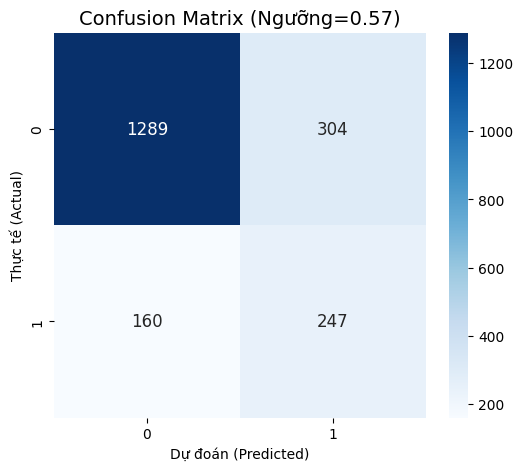


📌 BƯỚC 5: PHÂN TÍCH ĐẶC TRƯNG & BIỂU ĐỒ ROC

 Top 10 Đặc trưng quan trọng nhất:
             Feature  Coefficient  Abs_Coefficient  Odds_Ratio
0                Age     0.730931         0.730931    2.077014
1     IsActiveMember    -0.676455         0.676455    0.508416
2  Geography_Germany     0.610591         0.610591    1.841519
3             Gender    -0.415046         0.415046    0.660310
4            Balance     0.192210         0.192210    1.211925
5        CreditScore    -0.079292         0.079292    0.923770
6      NumOfProducts    -0.053656         0.053656    0.947758
7    EstimatedSalary     0.048276         0.048276    1.049461
8          HasCrCard    -0.020654         0.020654    0.979558
9             Tenure    -0.014901         0.014901    0.985210


/tmp/ipython-input-2402326591.py:153: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Abs_Coefficient", y="Feature", data=feature_importance.head(10), palette="viridis")


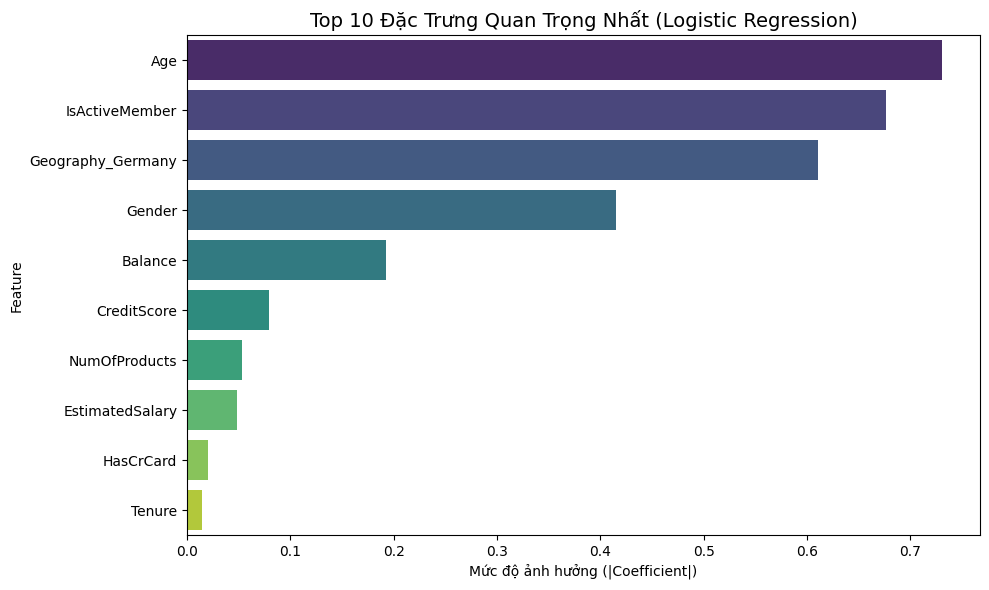

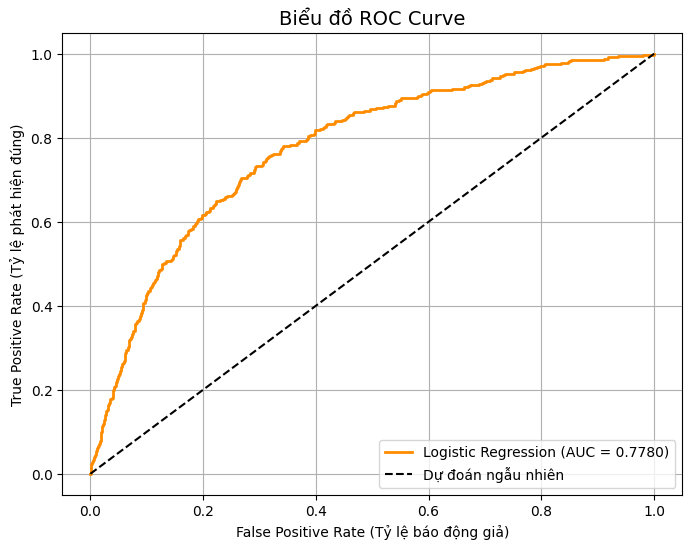

In [ ]:
# =============================================================================
# 1) LOGISTIC REGRESSION
# =============================================================================

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix, roc_auc_score, roc_curve,
    precision_recall_curve
)
from sklearn.model_selection import GridSearchCV
from statsmodels.stats.outliers_influence import variance_inflation_factor
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. KIỂM TRA ĐA CỘNG TUYẾN (VIF)
# Mục đích: Đảm bảo các biến đầu vào không bị trùng lặp thông tin (VIF < 5 là tốt).
print("\n" + "="*40)
print("📌 BƯỚC 1: KIỂM TRA ĐA CỘNG TUYẾN (VIF)")
print("="*40)

# Ép kiểu dữ liệu về số thực (float) để tránh lỗi tính toán
X_train = X_train.astype(float)
X_test = X_test.astype(float)

vif_data = pd.DataFrame()
vif_data["Feature"] = X_train.columns
vif_data["VIF"] = [variance_inflation_factor(X_train.values, i)
                   for i in range(len(X_train.columns))]

print(vif_data.sort_values(by="VIF", ascending=False))


# 2. TÌM THAM SỐ TỐT NHẤT (GRID SEARCH)
# Mục đích: Để máy tự tìm tham số C (Regularization) tốt nhất thay vì chọn bừa.
print("\n" + "="*40)
print("📌 BƯỚC 2: TỐI ƯU HÓA MÔ HÌNH (GRID SEARCH)")
print("="*40)

# Thiết lập lưới tham số để thử nghiệm
param_grid = {
    'C': [0.01, 0.1, 1, 10, 100],
    'solver': ['liblinear']        # Thuật toán tối ưu cho bài toán này
}

# Khởi tạo mô hình cơ sở (Có xử lý mất cân bằng lớp)
base_log_model = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)

# Chạy GridSearch với Cross-Validation (cv=5)
# scoring='roc_auc': Ưu tiên tối ưu hóa chỉ số AUC (tốt cho dữ liệu lệch)
grid_search = GridSearchCV(base_log_model, param_grid, cv=5, scoring='roc_auc', verbose=1)
grid_search.fit(X_train, y_train)

# Lưu lại mô hình tốt nhất
best_log_model = grid_search.best_estimator_

print(f"\n✅ Tham số tốt nhất (Best C): {grid_search.best_params_['C']}")
print(f"✅ AUC trung bình trên tập Train (CV): {grid_search.best_score_:.4f}")


# 3. TỐI ƯU NGƯỠNG DỰ ĐOÁN (THRESHOLD TUNING)
# Mục đích: Tìm ngưỡng cắt tốt nhất thay vì dùng mặc định 0.5.
print("\n" + "="*40)
print("📌 BƯỚC 3: TỐI ƯU NGƯỠNG (THRESHOLD TUNING)")
print("="*40)

# Tính xác suất dự đoán trên tập Test
log_proba = best_log_model.predict_proba(X_test)[:, 1]

# Tính Precision, Recall cho mọi ngưỡng
precisions, recalls, thresholds = precision_recall_curve(y_test, log_proba)

# Tính F1-Score cho từng ngưỡng và tìm ra điểm cao nhất
f1_scores = 2 * (precisions * recalls) / (precisions + recalls)
f1_scores = np.nan_to_num(f1_scores)  # Xử lý trường hợp chia cho 0 (nếu có)

best_f1_index = np.argmax(f1_scores)
best_threshold = thresholds[best_f1_index]

print(f"✅ Ngưỡng tối ưu (Best Threshold): {best_threshold:.4f}")
print(f"   (Nghĩa là xác suất >= {best_threshold:.1%} thì mới tính là Rời bỏ)")

# Tạo kết quả dự đoán cuối cùng dựa trên ngưỡng mới
final_pred = (log_proba >= best_threshold).astype(int)


# 4. ĐÁNH GIÁ HIỆU SUẤT & KIỂM TRA OVERFITTING
print("\n" + "="*40)
print("📌 BƯỚC 4: KẾT QUẢ ĐÁNH GIÁ CUỐI CÙNG")
print("="*40)

# --- A. Kiểm tra Overfitting ---
y_train_pred = best_log_model.predict(X_train)
train_acc = accuracy_score(y_train, y_train_pred)
test_acc = accuracy_score(y_test, final_pred)

print(f" KIỂM TRA OVERFITTING:")
print(f"   - Train Accuracy: {train_acc:.4f}")
print(f"   - Test Accuracy : {test_acc:.4f}")
if (train_acc - test_acc) > 0.1:
    print("   ⚠️ CẢNH BÁO: Chênh lệch > 10%, có thể bị Overfitting.")
else:
    print("   ✅ TỐT: Mô hình ổn định, không bị học vẹt.")

# --- B. Các chỉ số quan trọng ---
log_auc       = roc_auc_score(y_test, log_proba)
log_accuracy  = accuracy_score(y_test, final_pred)
log_precision = precision_score(y_test, final_pred)
log_recall    = recall_score(y_test, final_pred)
log_f1        = f1_score(y_test, final_pred)

print("\n CHỈ SỐ TRÊN TẬP TEST:")
print(f"    AUC Score : {log_auc:.4f}  (Quan trọng nhất)")
print(f"    Recall    : {log_recall:.4f}  (Quan trọng nhì - Bắt đúng khách rời bỏ)")
print(f"    Precision : {log_precision:.4f}")
print(f"    F1-Score  : {log_f1:.4f}")
print(f"    Accuracy  : {log_accuracy:.4f}")

print("\n CLASSIFICATION REPORT:")
print(classification_report(y_test, final_pred))

# --- C. Vẽ Confusion Matrix ---
plt.figure(figsize=(6, 5))
cm = confusion_matrix(y_test, final_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", annot_kws={"size": 12})
plt.title(f"Confusion Matrix (Ngưỡng={best_threshold:.2f})", fontsize=14)
plt.ylabel("Thực tế (Actual)")
plt.xlabel("Dự đoán (Predicted)")
plt.show()


# 5. TRỰC QUAN HÓA (FEATURE IMPORTANCE & ROC)
print("\n" + "="*40)
print("📌 BƯỚC 5: PHÂN TÍCH ĐẶC TRƯNG & BIỂU ĐỒ ROC")
print("="*40)

# --- A. Feature Importance (Tầm quan trọng đặc trưng) ---
coeffs = best_log_model.coef_[0]
feature_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Coefficient": coeffs,
    "Abs_Coefficient": np.abs(coeffs),
    "Odds_Ratio": np.exp(coeffs)
}).sort_values(by="Abs_Coefficient", ascending=False).reset_index(drop=True)

print("\n Top 10 Đặc trưng quan trọng nhất:")
print(feature_importance.head(10))

plt.figure(figsize=(10, 6))
# Đảo ngược thứ tự để cột quan trọng nhất nằm trên cùng nếu vẽ barh, hoặc bên trái nếu bar
sns.barplot(x="Abs_Coefficient", y="Feature", data=feature_importance.head(10), palette="viridis")
plt.title("Top 10 Đặc Trưng Quan Trọng Nhất (Logistic Regression)", fontsize=14)
plt.xlabel("Mức độ ảnh hưởng (|Coefficient|)")
plt.tight_layout()
plt.show()

# --- B. ROC Curve ---
fpr, tpr, _ = roc_curve(y_test, log_proba)
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, linewidth=2, label=f"Logistic Regression (AUC = {log_auc:.4f})", color='darkorange')
plt.plot([0, 1], [0, 1], 'k--', label="Dự đoán ngẫu nhiên")
plt.title("Biểu đồ ROC Curve", fontsize=14)
plt.xlabel("False Positive Rate (Tỷ lệ báo động giả)")
plt.ylabel("True Positive Rate (Tỷ lệ phát hiện đúng)")
plt.legend(loc="lower right")
plt.grid(True)
plt.show()


📌 BƯỚC 1: TÌM K TỐI ƯU (HYPERPARAMETER TUNING)


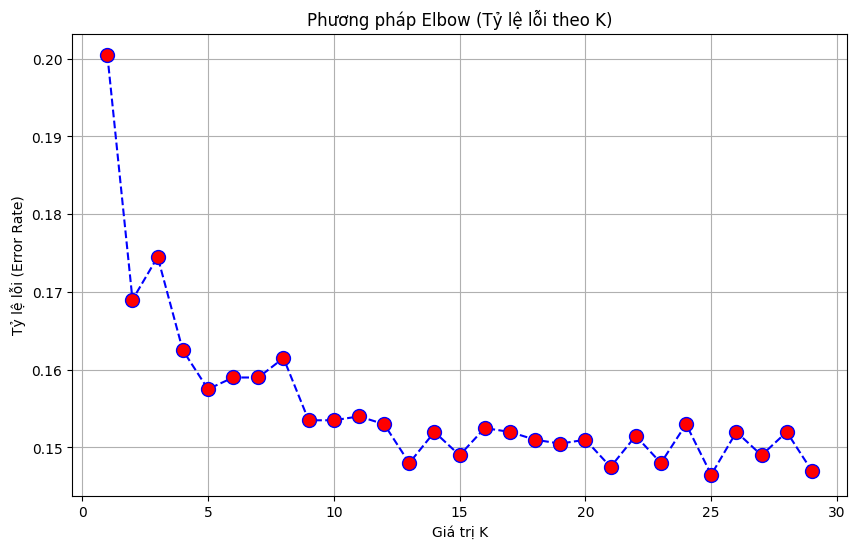

Fitting 5 folds for each of 28 candidates, totalling 140 fits
✅ Tham số tốt nhất: {'n_neighbors': 5, 'p': 2, 'weights': 'distance'}

📌 BƯỚC 2: TỐI ƯU NGƯỠNG (THRESHOLD TUNING)
✅ Ngưỡng tối ưu: 0.3441

📌 BƯỚC 3: KẾT QUẢ ĐÁNH GIÁ CUỐI CÙNG
 KIỂM TRA OVERFITTING:
   - Train Accuracy: 1.0000
   - Test Accuracy : 0.8045
   ⚠️ CẢNH BÁO: KNN đang bị Overfitting.

 CHỈ SỐ TRÊN TẬP TEST:
    AUC Score : 0.7963
    Recall    : 0.6093
    F1-Score  : 0.5592
    Accuracy  : 0.8045

 CLASSIFICATION REPORT:
              precision    recall  f1-score   support

           0       0.90      0.85      0.87      1593
           1       0.52      0.61      0.56       407

    accuracy                           0.80      2000
   macro avg       0.71      0.73      0.72      2000
weighted avg       0.82      0.80      0.81      2000



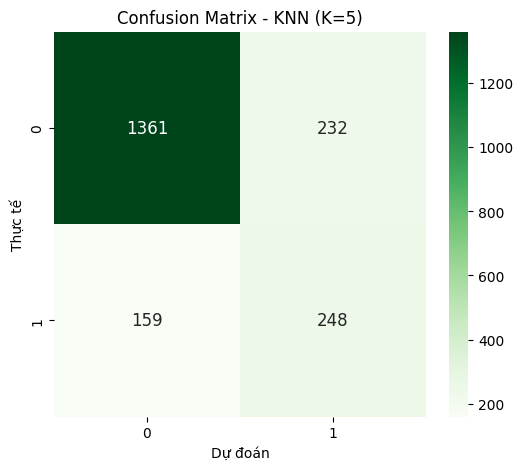


📌 BƯỚC 4: PHÂN TÍCH ĐẶC TRƯNG (PERMUTATION IMPORTANCE)
             Feature  Importance
5      NumOfProducts    0.194422
2                Age    0.143710
9  Geography_Germany    0.069615
7     IsActiveMember    0.043306
4            Balance    0.029014
1             Gender    0.013939
6          HasCrCard    0.011565
3             Tenure    0.005360
8    EstimatedSalary    0.001332
0        CreditScore   -0.006238


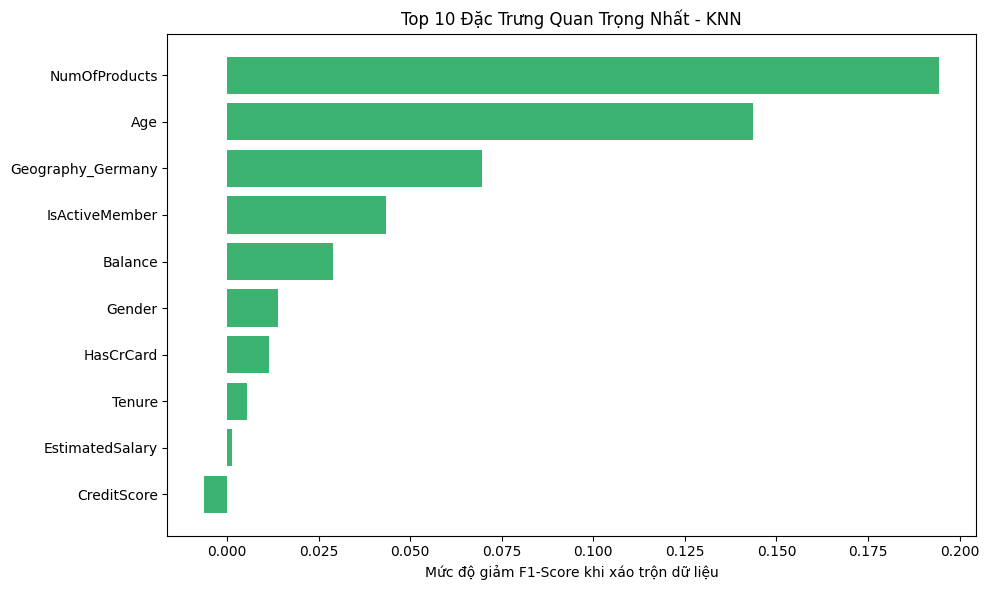

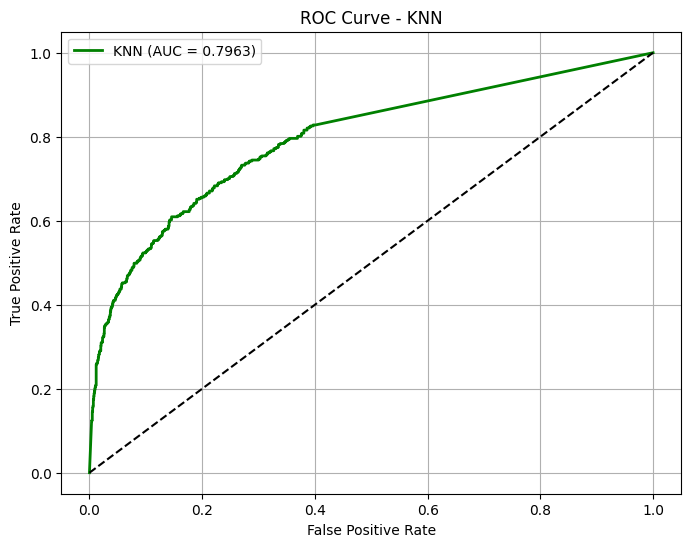

In [ ]:
# =============================================================================
# 2) K-NEAREST NEIGHBORS (KNN)
# =============================================================================

from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix, roc_auc_score, roc_curve,
    precision_recall_curve
)
from sklearn.model_selection import GridSearchCV
from sklearn.inspection import permutation_importance
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# 1. TÌM K TỐT NHẤT (ELBOW METHOD & GRID SEARCH)
print("\n" + "="*40)
print("📌 BƯỚC 1: TÌM K TỐI ƯU (HYPERPARAMETER TUNING)")
print("="*40)

# --- Cách 1: Vẽ biểu đồ Elbow (Khuỷu tay) để nhìn xu hướng ---
error_rate = []
for i in range(1, 30): # Thử K từ 1 đến 30
    knn = KNeighborsClassifier(n_neighbors=i)
    knn.fit(X_train, y_train)
    pred_i = knn.predict(X_test)
    error_rate.append(np.mean(pred_i != y_test))

plt.figure(figsize=(10,6))
plt.plot(range(1, 30), error_rate, color='blue', linestyle='dashed', marker='o',
         markerfacecolor='red', markersize=10)
plt.title('Phương pháp Elbow (Tỷ lệ lỗi theo K)')
plt.xlabel('Giá trị K')
plt.ylabel('Tỷ lệ lỗi (Error Rate)')
plt.grid(True)
plt.show()

# --- Cách 2: Dùng GridSearch để máy tự chọn số tối ưu nhất ---
param_grid = {
    'n_neighbors': [3, 5, 7, 9, 11, 15, 21],      # Các số lẻ để tránh hòa vốn
    'weights': ['uniform', 'distance'],           # distance: Hàng xóm gần có tiếng nói lớn hơn (Tốt cho imbalanced)
    'p': [1, 2]                                   # 1: Manhattan, 2: Euclidean
}

knn = KNeighborsClassifier()
knn_cv = GridSearchCV(knn, param_grid, cv=5, scoring='f1', verbose=1)
knn_cv.fit(X_train, y_train)

best_knn = knn_cv.best_estimator_

print(f"✅ Tham số tốt nhất: {knn_cv.best_params_}")
# Ví dụ: Nếu nó chọn weights='distance', nghĩa là nó đang cố gắng xử lý mất cân bằng dữ liệu

# 2. TỐI ƯU NGƯỠNG (THRESHOLD TUNING)
print("\n" + "="*40)
print("📌 BƯỚC 2: TỐI ƯU NGƯỠNG (THRESHOLD TUNING)")
print("="*40)

# Dự đoán xác suất
knn_proba = best_knn.predict_proba(X_test)[:, 1]

# Tìm ngưỡng F1 cao nhất
precisions, recalls, thresholds = precision_recall_curve(y_test, knn_proba)
f1_scores = 2 * (precisions * recalls) / (precisions + recalls)
f1_scores = np.nan_to_num(f1_scores)

best_f1_index = np.argmax(f1_scores)
best_threshold = thresholds[best_f1_index]

print(f"✅ Ngưỡng tối ưu: {best_threshold:.4f}")

# Tạo dự đoán cuối cùng
final_pred = (knn_proba >= best_threshold).astype(int)

# 3. ĐÁNH GIÁ HIỆU SUẤT
print("\n" + "="*40)
print("📌 BƯỚC 3: KẾT QUẢ ĐÁNH GIÁ CUỐI CÙNG")
print("="*40)

# Overfitting Check
y_train_pred = best_knn.predict(X_train)
train_acc = accuracy_score(y_train, y_train_pred)
test_acc = accuracy_score(y_test, final_pred)

print(f" KIỂM TRA OVERFITTING:")
print(f"   - Train Accuracy: {train_acc:.4f}")
print(f"   - Test Accuracy : {test_acc:.4f}")
if train_acc - test_acc > 0.15: # KNN thường dễ overfit hơn LR nên để ngưỡng 15%
    print("   ⚠️ CẢNH BÁO: KNN đang bị Overfitting.")
else:
    print("   ✅ TỐT: Mô hình ổn định.")

# Metrics
knn_auc = roc_auc_score(y_test, knn_proba)
print("\n CHỈ SỐ TRÊN TẬP TEST:")
print(f"    AUC Score : {knn_auc:.4f}")
print(f"    Recall    : {recall_score(y_test, final_pred):.4f}")
print(f"    F1-Score  : {f1_score(y_test, final_pred):.4f}")
print(f"    Accuracy  : {accuracy_score(y_test, final_pred):.4f}")

print("\n CLASSIFICATION REPORT:")
print(classification_report(y_test, final_pred))

# Confusion Matrix
plt.figure(figsize=(6, 5))
cm = confusion_matrix(y_test, final_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Greens", annot_kws={"size": 12})
plt.title(f"Confusion Matrix - KNN (K={knn_cv.best_params_['n_neighbors']})")
plt.ylabel("Thực tế")
plt.xlabel("Dự đoán")
plt.show()

# 4. FEATURE IMPORTANCE (PERMUTATION IMPORTANCE)
# KNN không có feature_importances_ có sẵn nên phải dùng kỹ thuật này
print("\n" + "="*40)
print("📌 BƯỚC 4: PHÂN TÍCH ĐẶC TRƯNG (PERMUTATION IMPORTANCE)")
print("="*40)

perm_result = permutation_importance(
    best_knn, X_test, y_test,
    n_repeats=10,
    random_state=42,
    scoring='f1' # Đánh giá độ quan trọng dựa trên việc làm giảm F1-score
)

importance_knn = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": perm_result.importances_mean
}).sort_values(by="Importance", ascending=False)

print(importance_knn.head(10))

# Vẽ biểu đồ
plt.figure(figsize=(10, 6))
# Đảo ngược trục Y để cái quan trọng nhất nằm trên cùng
plt.barh(importance_knn["Feature"].head(10)[::-1], importance_knn["Importance"].head(10)[::-1], color='mediumseagreen')
plt.title("Top 10 Đặc Trưng Quan Trọng Nhất - KNN")
plt.xlabel("Mức độ giảm F1-Score khi xáo trộn dữ liệu")
plt.tight_layout()
plt.show()

# ROC Curve
fpr, tpr, _ = roc_curve(y_test, knn_proba)
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, linewidth=2, label=f"KNN (AUC = {knn_auc:.4f})", color='green')
plt.plot([0, 1], [0, 1], 'k--')
plt.title("ROC Curve - KNN")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.grid(True)
plt.show()

⏳ Đang tìm tham số tốt nhất cho Decision Tree...
✅ Tham số tối ưu: {'criterion': 'entropy', 'max_depth': 10, 'min_samples_split': 20}
 Train Acc: 0.8865
 Test Acc : 0.8470
Accuracy: 0.847

Classification Report:
               precision    recall  f1-score   support

           0       0.87      0.95      0.91      1593
           1       0.68      0.46      0.55       407

    accuracy                           0.85      2000
   macro avg       0.78      0.70      0.73      2000
weighted avg       0.83      0.85      0.84      2000


Confusion Matrix:
 [[1506   87]
 [ 219  188]]


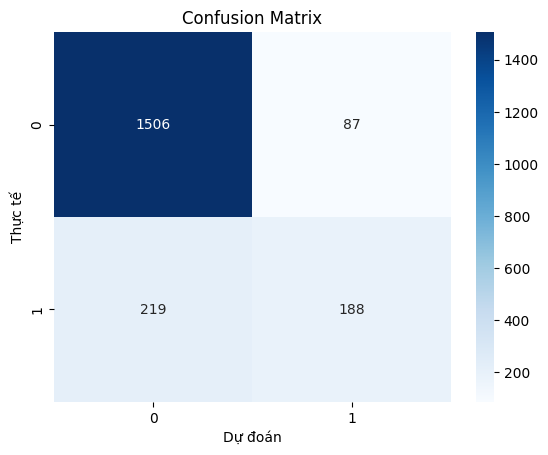

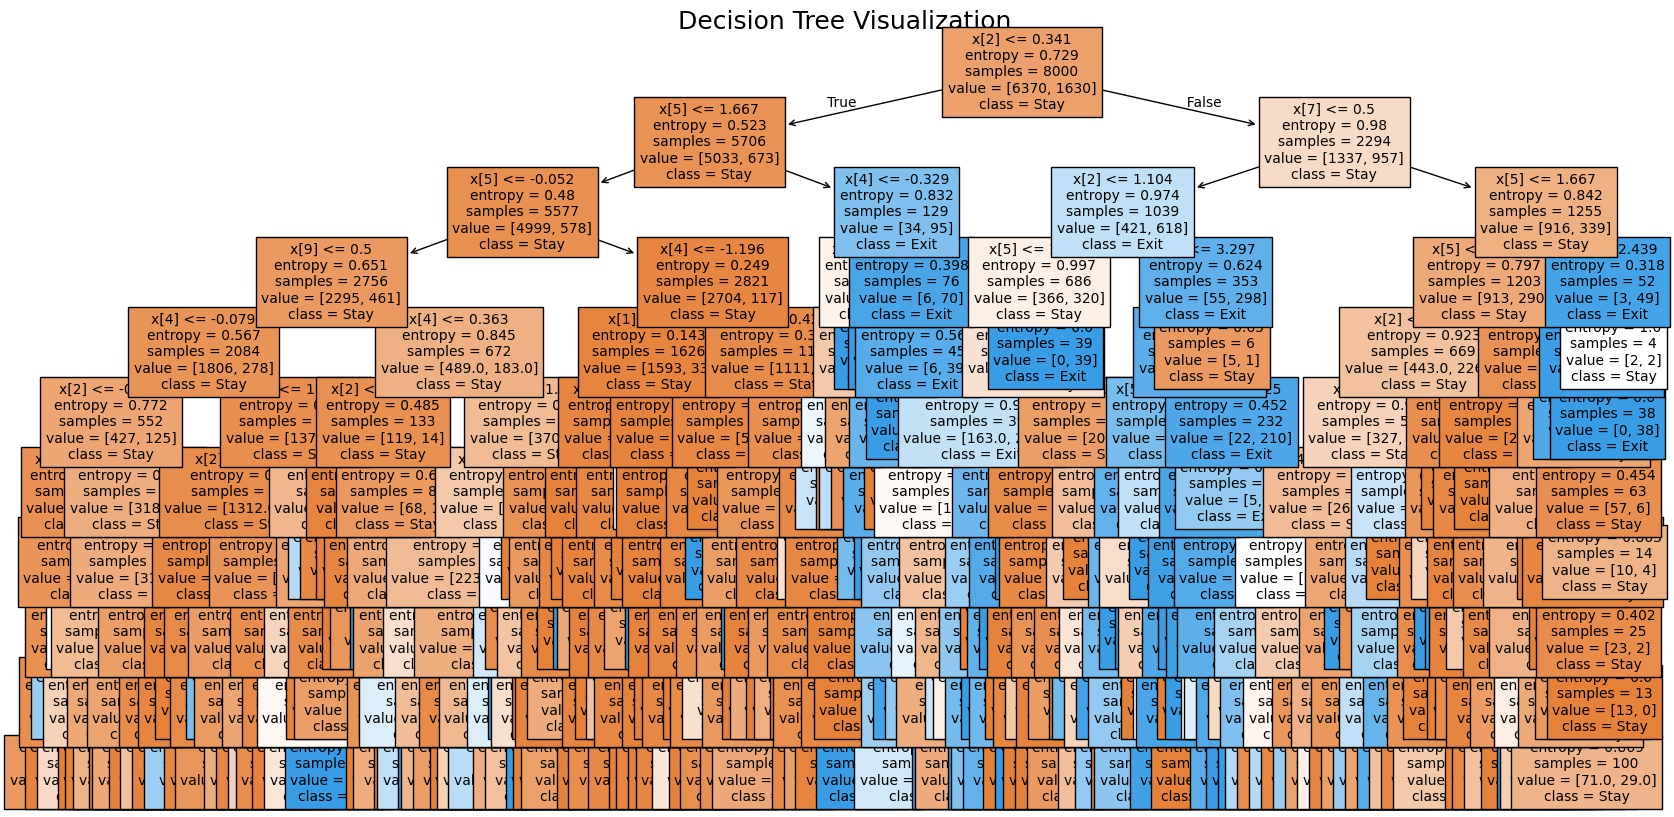


=== Độ quan trọng của các đặc trưng ===
              Feature  Importance
2                 Age    0.320546
5       NumOfProducts    0.233157
4             Balance    0.137988
8     EstimatedSalary    0.078295
7      IsActiveMember    0.071614
0         CreditScore    0.067174
9   Geography_Germany    0.038567
3              Tenure    0.026518
1              Gender    0.014529
10    Geography_Spain    0.007400
6           HasCrCard    0.004211


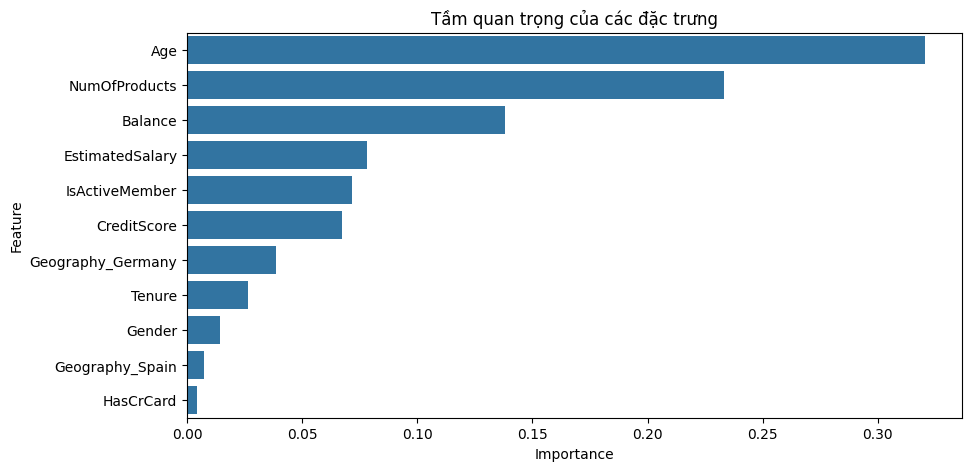

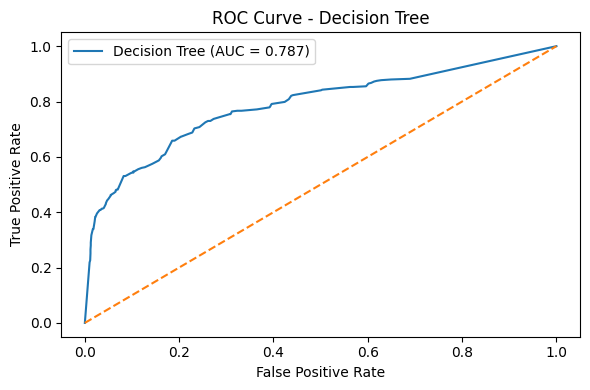

In [ ]:
# ============================================================
# 3) DECISION TREE
# ============================================================

# 1. Import thư viện
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_curve, roc_auc_score
import matplotlib.pyplot as plt
import seaborn as sns

# 2. Khởi tạo và huấn luyện mô hình Decision Tree

# --- TỐI ƯU HÓA (GridSearch) ---
param_grid_dt = {
    'max_depth': [5, 10, 15, None],
    'min_samples_split': [2, 10, 20],
    'criterion': ['gini', 'entropy']
}

print("⏳ Đang tìm tham số tốt nhất cho Decision Tree...")
dt_grid = GridSearchCV(DecisionTreeClassifier(random_state=42), param_grid_dt, cv=5, scoring='f1')
dt_grid.fit(X_train, y_train)

dt_model = dt_grid.best_estimator_ # Lấy mô hình tốt nhất
print(f"✅ Tham số tối ưu: {dt_grid.best_params_}")

# --- KIỂM TRA OVERFITTING ---
print(f" Train Acc: {accuracy_score(y_train, dt_model.predict(X_train)):.4f}")
print(f" Test Acc : {accuracy_score(y_test, dt_model.predict(X_test)):.4f}")

# 3. Dự đoán trên tập test
y_pred_dt = dt_model.predict(X_test)

# 4. Đánh giá mô hình
print("Accuracy:", accuracy_score(y_test, y_pred_dt))
print("\nClassification Report:\n", classification_report(y_test, y_pred_dt))
cm = confusion_matrix(y_test, y_pred_dt) # Gán ma trận nhầm lẫn vào biến cm
print("\nConfusion Matrix:\n", cm)
# Vẽ ma trận nhầm lẫn
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.xlabel("Dự đoán")
plt.ylabel("Thực tế")
plt.show()


# 5. Vẽ cây quyết định
from sklearn.tree import plot_tree

plt.figure(figsize=(20,10))
plot_tree(dt_model, class_names=['Stay', 'Exit'], filled=True, fontsize=10)
plt.title("Decision Tree Visualization", fontsize=18)
plt.show()

# 6. Phân tích tầm quan trọng của các đặc trưng (Feature Importance)
feature_importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': dt_model.feature_importances_
}).sort_values(by='Importance', ascending=False)

print("\n=== Độ quan trọng của các đặc trưng ===")
print(feature_importance)

# Biểu đồ trực quan
plt.figure(figsize=(10,5))
sns.barplot(x='Importance', y='Feature', data=feature_importance)
plt.title("Tầm quan trọng của các đặc trưng")
plt.show()

# Vẽ ROC CURVE
y_proba_dt = dt_model.predict_proba(X_test)[:, 1] # Thêm dòng này để tính xác suất dự đoán
fpr_dt, tpr_dt, thresholds_dt = roc_curve(y_test, y_proba_dt)
auc_dt = roc_auc_score(y_test, y_proba_dt)

plt.figure(figsize=(6,4))
plt.plot(fpr_dt, tpr_dt, label=f"Decision Tree (AUC = {auc_dt:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--")  # đường đoán ngẫu nhiên
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Decision Tree")
plt.legend()
plt.tight_layout()
plt.show()


⏳ Đang chạy GridSearch tìm tham số tối ưu...
Fitting 3 folds for each of 27 candidates, totalling 81 fits
✅ Tham số tốt nhất: {'max_depth': 10, 'min_samples_leaf': 2, 'n_estimators': 100}

 KIỂM TRA ĐỘ ỔN ĐỊNH (OVERFITTING):
   - Train Accuracy: 0.8998
   - Test Accuracy : 0.8390
   ✅ TỐT: Mô hình ổn định (Chênh lệch thấp).
Accuracy: 0.839

Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.89      0.90      1593
           1       0.60      0.65      0.62       407

    accuracy                           0.84      2000
   macro avg       0.75      0.77      0.76      2000
weighted avg       0.84      0.84      0.84      2000


Confusion Matrix:
[[1415  178]
 [ 144  263]]


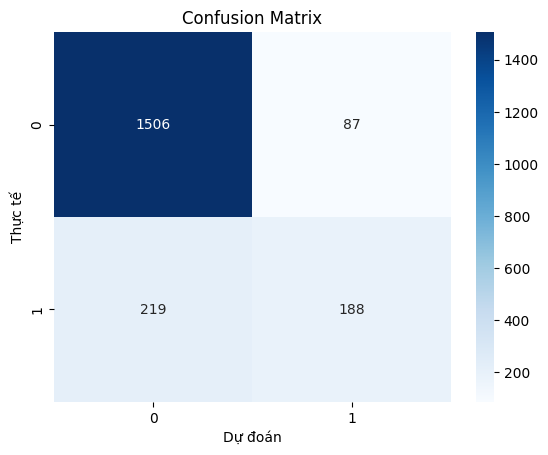

=== Độ quan trọng của các đặc trưng (Random Forest) ===
              Feature  Importance
0                 Age    0.320202
1       NumOfProducts    0.206918
2             Balance    0.120640
3     EstimatedSalary    0.080397
4         CreditScore    0.078093
5   Geography_Germany    0.054022
6      IsActiveMember    0.053635
7              Tenure    0.043253
8              Gender    0.022357
9           HasCrCard    0.010415
10    Geography_Spain    0.010065


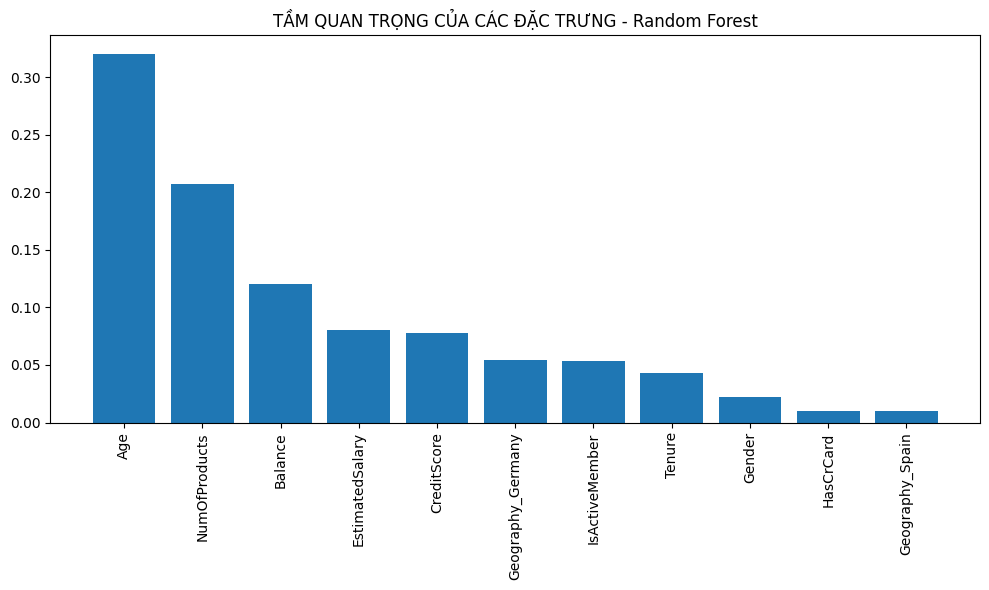

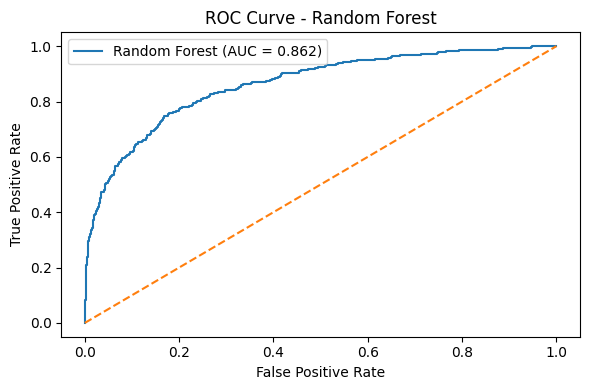

In [ ]:
# ============================================================
# 4) RANDOM FOREST CLASSIFIER
# ============================================================

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_curve, roc_auc_score
import matplotlib.pyplot as plt

import numpy as np

print("⏳ Đang chạy GridSearch tìm tham số tối ưu...")
# 1. Định nghĩa lưới tham số muốn thử
param_grid_rf = {
    'n_estimators': [100, 200, 300],      # Thử các số lượng cây khác nhau
    'max_depth': [10, 15, 20],            # Giới hạn độ sâu để tránh học vẹt (Thay vì None)
    'min_samples_leaf': [1, 2, 4]         # Tăng số lượng mẫu ở lá để cây tổng quát hơn
}

# 2. Chạy tìm kiếm
rf_base = RandomForestClassifier(random_state=42, class_weight='balanced')
rf_grid = GridSearchCV(rf_base, param_grid_rf, cv=3, scoring='f1', verbose=1, n_jobs=-1)
rf_grid.fit(X_train, y_train)

# 3. Lấy ra mô hình tốt nhất
rf_model = rf_grid.best_estimator_
print(f"✅ Tham số tốt nhất: {rf_grid.best_params_}")

# 4. Kiểm tra overfitting
print("\n KIỂM TRA ĐỘ ỔN ĐỊNH (OVERFITTING):")
train_acc = accuracy_score(y_train, rf_model.predict(X_train))
test_acc = accuracy_score(y_test, rf_model.predict(X_test))

print(f"   - Train Accuracy: {train_acc:.4f}")
print(f"   - Test Accuracy : {test_acc:.4f}")

if train_acc - test_acc > 0.15:
    print("   ⚠️ CẢNH BÁO: Chênh lệch > 15% -> Có dấu hiệu Overfitting.")
else:
    print("   ✅ TỐT: Mô hình ổn định (Chênh lệch thấp).")

# 5. Dự đoán trên tập test
rf_pred = rf_model.predict(X_test)

# 6. Đánh giá mô hình
print("Accuracy:", accuracy_score(y_test, rf_pred))

print("\nClassification Report:")
print(classification_report(y_test, rf_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, rf_pred))
# Vẽ ma trận nhầm lẫn
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.xlabel("Dự đoán")
plt.ylabel("Thực tế")
plt.show()


# 7. Phân tích và vẽ tầm quan trọng của các đặc trưng
feature_importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': rf_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by='Importance', ascending=False
).reset_index(drop=True)

print("=== Độ quan trọng của các đặc trưng (Random Forest) ===")
print(feature_importance)


plt.figure(figsize=(10, 6))
plt.bar(feature_importance['Feature'], feature_importance['Importance'])
plt.xticks(rotation=90)
plt.title("TẦM QUAN TRỌNG CỦA CÁC ĐẶC TRƯNG - Random Forest")
plt.tight_layout()
plt.show()

# 8. VẼ ROC CURVE CHO RANDOM FOREST

rf_proba = rf_model.predict_proba(X_test)[:, 1] # Lấy xác suất của lớp dương
fpr, tpr, thresholds = roc_curve(y_test, rf_proba)
rf_auc = roc_auc_score(y_test, rf_proba)

plt.figure(figsize=(6, 4))
plt.plot(fpr, tpr, label=f"Random Forest (AUC = {rf_auc:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--")  # đường đoán ngẫu nhiên
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Random Forest")
plt.legend()
plt.tight_layout()
plt.show()

 Tỷ lệ Scale Pos Weight: 3.91
⏳ Đang tìm tham số tối ưu cho XGBoost...
Fitting 3 folds for each of 18 candidates, totalling 54 fits
✅ Tham số tối ưu: {'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 100}

 KIỂM TRA OVERFITTING:
   - Train Accuracy: 0.8514
   - Test Accuracy : 0.8015
   ✅ Tốt: Mô hình ổn định.
 Accuracy: 0.8015

 Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.82      0.87      1593
           1       0.51      0.73      0.60       407

    accuracy                           0.80      2000
   macro avg       0.72      0.77      0.73      2000
weighted avg       0.84      0.80      0.81      2000


 Confusion Matrix:
[[1307  286]
 [ 111  296]]


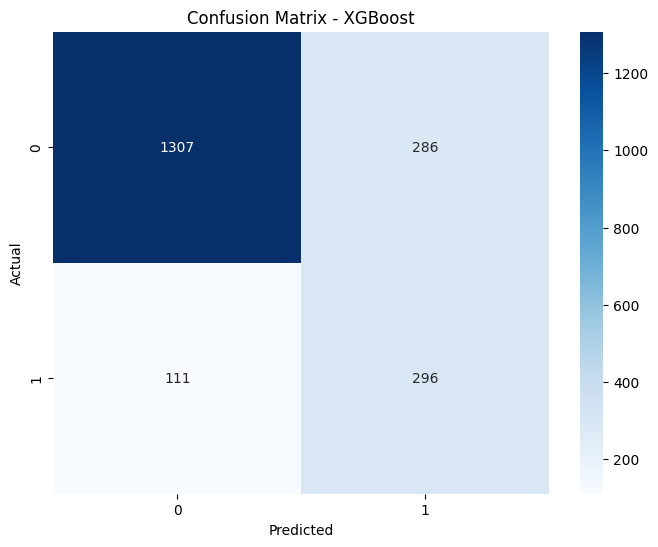

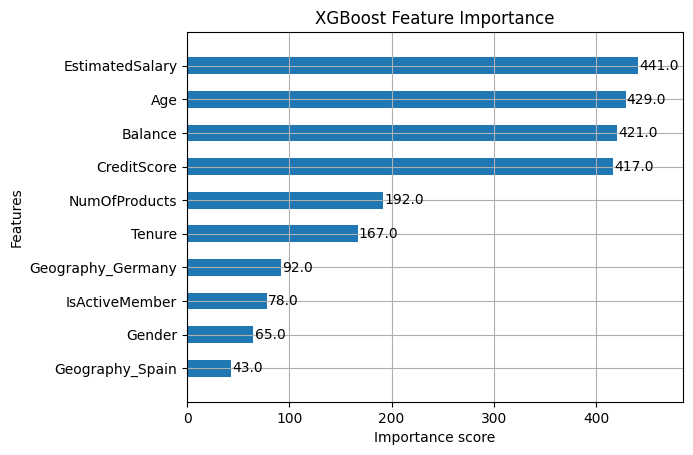

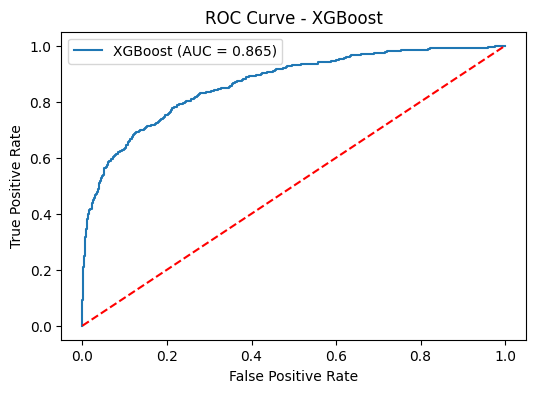

In [ ]:
# ============================================================
# 5) XGBOOST CLASSIFIER
# ============================================================

import xgboost as xgb
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_curve, roc_auc_score
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Tính tỷ lệ mất cân bằng
# Tỷ lệ = Số lượng mẫu Âm (0) / Số lượng mẫu Dương (1)
ratio_value = float(np.sum(y_train == 0)) / np.sum(y_train == 1)
print(f" Tỷ lệ Scale Pos Weight: {ratio_value:.2f}")

# 2. Dùng GridSearch thay vì khởi tạo thủ công
from sklearn.model_selection import GridSearchCV

# Thiết lập lưới tham số để máy tự thử
param_grid_xgb = {
    'n_estimators': [100, 200, 300],       # Thử các số lượng cây
    'max_depth': [3, 5, 7],                # Thử độ sâu khác nhau
    'learning_rate': [0.05, 0.1]           # Thử tốc độ học
}

# Khởi tạo mô hình cơ sở (thêm scale_pos_weight vào đây)
xgb_base = xgb.XGBClassifier(
    scale_pos_weight=ratio_value,          # <--- QUAN TRỌNG NHẤT
    random_state=42,
    eval_metric='logloss'
)

# Chạy tìm kiếm
print("⏳ Đang tìm tham số tối ưu cho XGBoost...")
xgb_grid = GridSearchCV(xgb_base, param_grid_xgb, cv=3, scoring='f1', verbose=1)
xgb_grid.fit(X_train, y_train)

# Lấy mô hình tốt nhất gán ngược lại vào biến xgb_model để các đoạn sau vẫn chạy đúng
xgb_model = xgb_grid.best_estimator_
print(f"✅ Tham số tối ưu: {xgb_grid.best_params_}")

# 3. Kiểm tra overfitting
print("\n KIỂM TRA OVERFITTING:")
train_acc = accuracy_score(y_train, xgb_model.predict(X_train))
test_acc = accuracy_score(y_test, xgb_model.predict(X_test)) # Dùng tạm để so sánh

print(f"   - Train Accuracy: {train_acc:.4f}")
print(f"   - Test Accuracy : {test_acc:.4f}")

if train_acc - test_acc > 0.15:
    print("   ⚠️ Cảnh báo: XGBoost có dấu hiệu Overfitting.")
else:
    print("   ✅ Tốt: Mô hình ổn định.")

# 4. Dự đoán
xgb_pred = xgb_model.predict(X_test)
xgb_proba = xgb_model.predict_proba(X_test)[:, 1] # Xác suất dự đoán lớp 1

# 5. Đánh giá mô hình
print(" Accuracy:", accuracy_score(y_test, xgb_pred))

print("\n Classification Report:")
print(classification_report(y_test, xgb_pred))

print("\n Confusion Matrix:")
cm_xgb = confusion_matrix(y_test, xgb_pred)
print(cm_xgb)

# Plot Confusion Matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm_xgb, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix - XGBoost')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# 6. Feature Importance
xgb.plot_importance(xgb_model, max_num_features=10, height=0.5)
plt.title("XGBoost Feature Importance")
plt.show()

# Plot ROC Curve
fpr_xgb, tpr_xgb, thresholds_xgb = roc_curve(y_test, xgb_proba)
auc_xgb = roc_auc_score(y_test, xgb_proba)

plt.figure(figsize=(6, 4))
plt.plot(fpr_xgb, tpr_xgb, label=f'XGBoost (AUC = {auc_xgb:.3f})')
plt.plot([0, 1], [0, 1], 'r--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - XGBoost')
plt.legend()
plt.show()

⏳ Đang tìm tham số tối ưu cho LightGBM...
Fitting 3 folds for each of 36 candidates, totalling 108 fits
✅ Tham số tối ưu: {'learning_rate': 0.05, 'max_depth': 20, 'n_estimators': 100, 'num_leaves': 50}

 KIỂM TRA OVERFITTING:
   - Train Accuracy: 0.8836
   - Test Accuracy : 0.8120
   ✅ Tốt: Mô hình ổn định.
 Accuracy: 0.812

 Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.84      0.88      1593
           1       0.53      0.71      0.61       407

    accuracy                           0.81      2000
   macro avg       0.72      0.77      0.74      2000
weighted avg       0.84      0.81      0.82      2000


 Confusion Matrix:
[[1334  259]
 [ 117  290]]


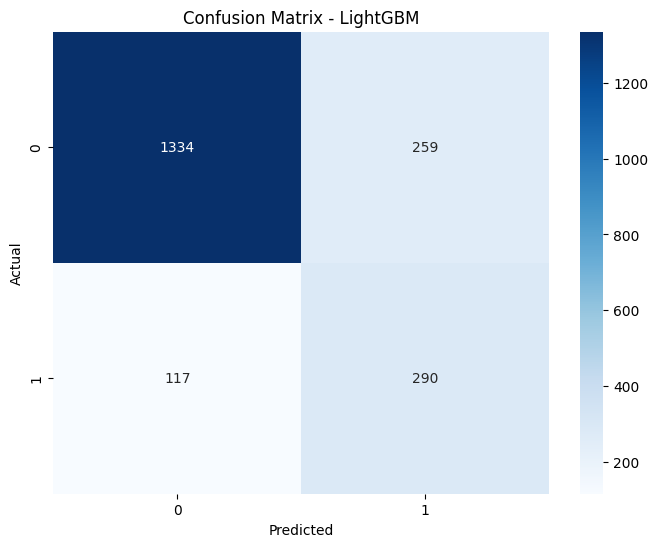

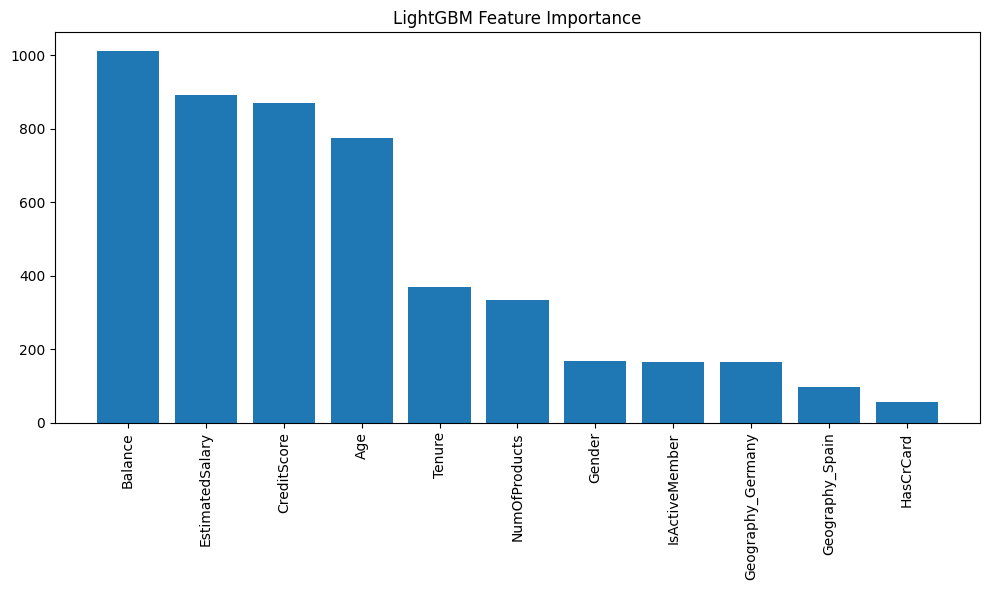

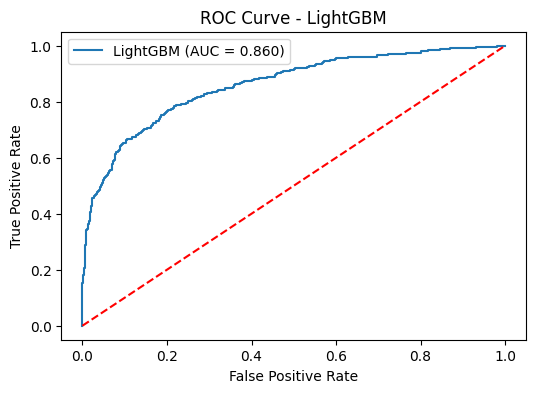

In [ ]:
# ============================================================
# 6) LIGHTGBM CLASSIFIER
# ============================================================

import lightgbm as lgb
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_curve, roc_auc_score
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

# 1. Dùng GridSearch và Tự động cân bằng
from sklearn.model_selection import GridSearchCV

# Thiết lập lưới tham số để máy tự thử
param_grid_lgb = {
    'n_estimators': [100, 200, 300],      # Thử số lượng cây
    'learning_rate': [0.05, 0.1],         # Thử tốc độ học
    'num_leaves': [31, 50],               # Độ phức tạp của cây
    'max_depth': [-1, 10, 20]             # Giới hạn độ sâu
}

# 2. Khởi tạo mô hình cơ sở
# QUAN TRỌNG: Thêm class_weight='balanced' để tự động xử lý mất cân bằng
lgb_base = lgb.LGBMClassifier(
    class_weight='balanced',
    random_state=42,
    verbose=-1                            # Tắt thông báo rác
)

# Chạy tìm kiếm
print("⏳ Đang tìm tham số tối ưu cho LightGBM...")
lgb_grid = GridSearchCV(lgb_base, param_grid_lgb, cv=3, scoring='f1', verbose=1)
lgb_grid.fit(X_train, y_train)

# Lấy mô hình tốt nhất gán ngược lại vào biến lgb_model
lgb_model = lgb_grid.best_estimator_
print(f"✅ Tham số tối ưu: {lgb_grid.best_params_}")

# 3. Kiểm tra overfitting
print("\n KIỂM TRA OVERFITTING:")
train_acc = accuracy_score(y_train, lgb_model.predict(X_train))
test_acc = accuracy_score(y_test, lgb_model.predict(X_test)) # Dùng tạm để so sánh

print(f"   - Train Accuracy: {train_acc:.4f}")
print(f"   - Test Accuracy : {test_acc:.4f}")

if train_acc - test_acc > 0.1:
    print("   ⚠️ Cảnh báo: LightGBM có dấu hiệu Overfitting.")
else:
    print("   ✅ Tốt: Mô hình ổn định.")

# 4. Dự đoán
lgb_pred = lgb_model.predict(X_test)
lgb_proba = lgb_model.predict_proba(X_test)[:, 1] # Xác suất dự đoán lớp 1

# 5. Đánh giá mô hình
print(" Accuracy:", accuracy_score(y_test, lgb_pred))

print("\n Classification Report:")
print(classification_report(y_test, lgb_pred))

print("\n Confusion Matrix:")
cm_lgb = confusion_matrix(y_test, lgb_pred)
print(cm_lgb)

# Plot Confusion Matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm_lgb, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix - LightGBM')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# ============================================================
# 6. Feature Importance
# ============================================================

importances = lgb_model.feature_importances_
indices = np.argsort(importances)[::-1]
features = X_train.columns

plt.figure(figsize=(10,6))
plt.bar(range(len(importances)), importances[indices])
plt.xticks(range(len(importances)), features[indices], rotation=90)
plt.title("LightGBM Feature Importance")
plt.tight_layout()
plt.show()

# Plot ROC Curve
fpr_lgb, tpr_lgb, thresholds_lgb = roc_curve(y_test, lgb_proba)
auc_lgb = roc_auc_score(y_test, lgb_proba)

plt.figure(figsize=(6, 4))
plt.plot(fpr_lgb, tpr_lgb, label=f'LightGBM (AUC = {auc_lgb:.3f})')
plt.plot([0, 1], [0, 1], 'r--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - LightGBM')
plt.legend()
plt.show()


 BẢNG TỔNG HỢP KẾT QUẢ:


,Model,Accuracy,Precision,Recall,F1-Score,AUC
3,Random Forest,0.839000,0.596372,0.646192,0.620283,0.862221
5,LightGBM,0.812000,0.528233,0.712531,0.606695,0.859590
4,XGBoost,0.801500,0.508591,0.727273,0.598584,0.865215
2,Decision Tree,0.847000,0.683636,0.461916,0.551320,0.787015
1,KNN,0.843000,0.683794,0.425061,0.524242,0.796299
0,Logistic Regression,0.720500,0.395317,0.705160,0.506620,0.777967


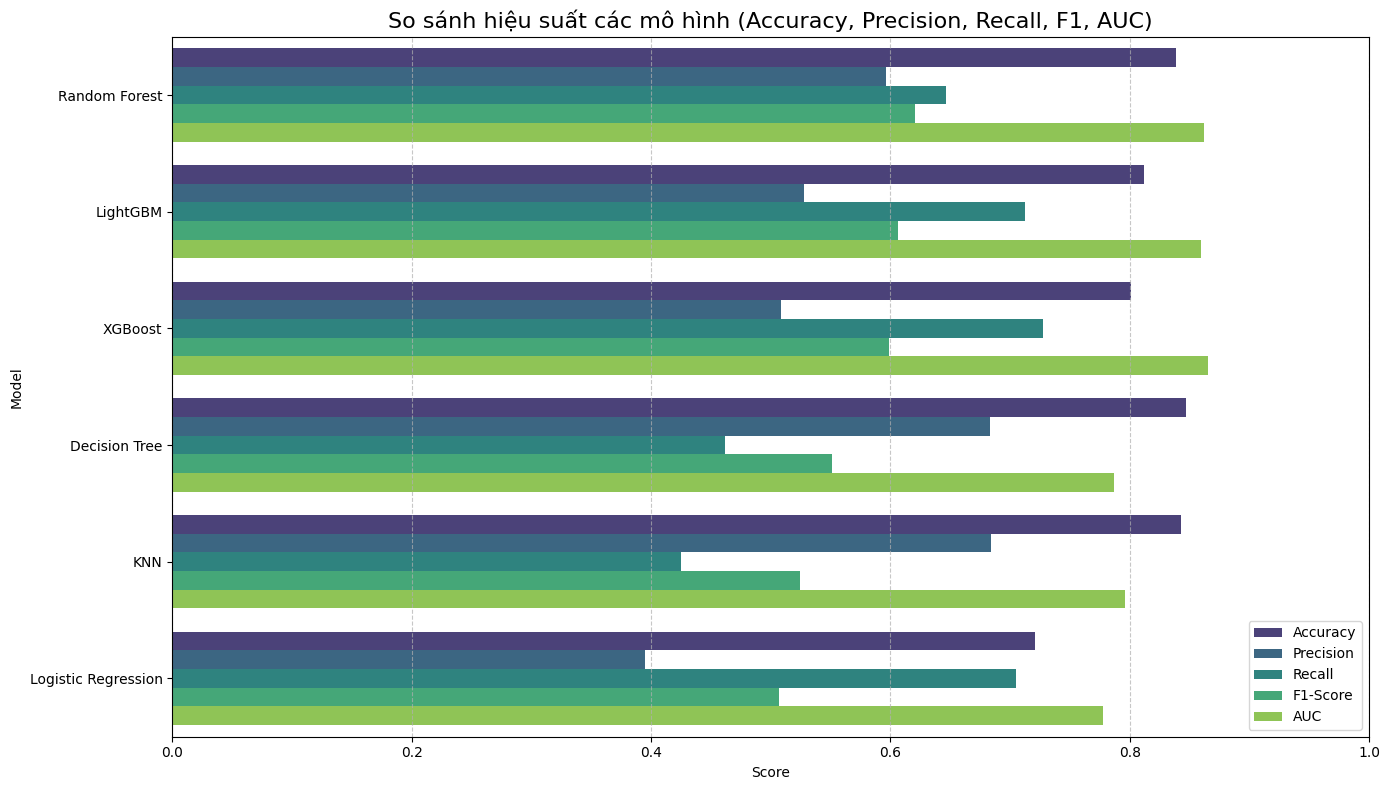

/tmp/ipython-input-567886725.py:72: UserWarning: linestyle is redundantly defined by the 'linestyle' keyword argument and the fmt string "k--" (-> linestyle='--'). The keyword argument will take precedence.
  plt.plot([0, 1], [0, 1], 'k--', linestyle='--') # Đường ngẫu nhiên


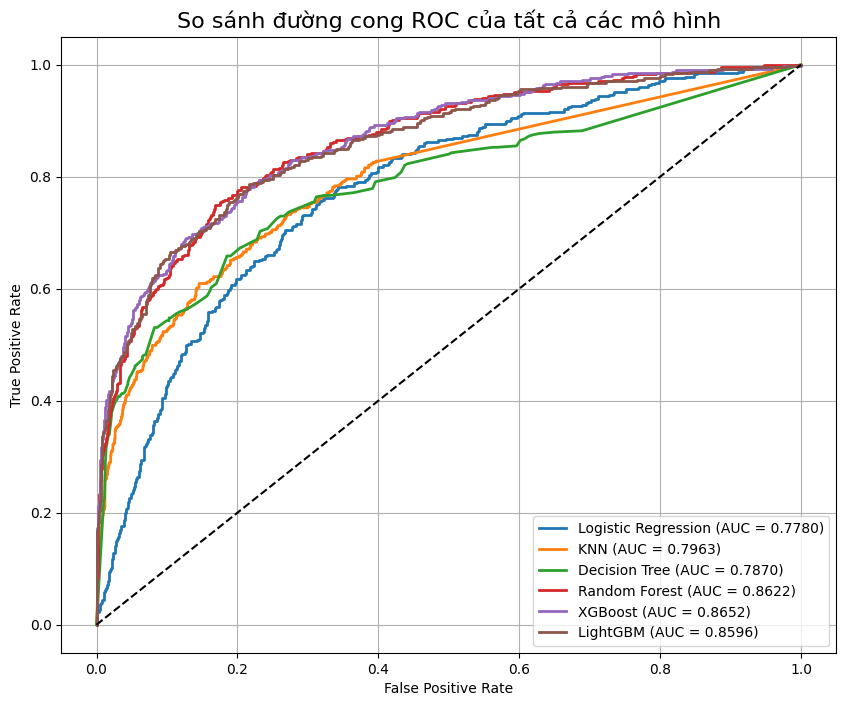

In [ ]:
# =============================================================================
# SO SÁNH & ĐÁNH GIÁ TỔNG HỢP 6 MÔ HÌNH
# =============================================================================

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. TẬP HỢP CÁC MÔ HÌNH
models = {
    "Logistic Regression": best_log_model,
    "KNN": best_knn,
    "Decision Tree": dt_model,
    "Random Forest": rf_model,
    "XGBoost": xgb_model,
    "LightGBM": lgb_model
}

results = []

for name, model in models.items():
    # Dự đoán nhãn
    y_pred = model.predict(X_test)
    # Dự đoán xác suất (cần cho AUC)
    y_proba = model.predict_proba(X_test)[:, 1]

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1-Score": f1_score(y_test, y_pred),
        "AUC": roc_auc_score(y_test, y_proba)
    })

# 2. TẠO BẢNG KẾT QUẢ (DATAFRAME)
results_df = pd.DataFrame(results)
# Sắp xếp theo F1-Score (hoặc AUC) vì đây là chỉ số quan trọng cho Churn
results_df = results_df.sort_values(by="F1-Score", ascending=False)

print("\n BẢNG TỔNG HỢP KẾT QUẢ:")
display(results_df.style.background_gradient(cmap='Blues')) # Tô màu cho đẹp


# =============================================================================
# TRỰC QUAN HÓA SO SÁNH
# =============================================================================

# 3. BIỂU ĐỒ CỘT SO SÁNH CÁC CHỈ SỐ
# Chuyển đổi dữ liệu sang dạng dài (long format) để vẽ seaborn
results_melted = results_df.melt(id_vars="Model", var_name="Metric", value_name="Score")

plt.figure(figsize=(14, 8))
sns.barplot(x="Score", y="Model", hue="Metric", data=results_melted, palette="viridis")
plt.title("So sánh hiệu suất các mô hình (Accuracy, Precision, Recall, F1, AUC)", fontsize=16)
plt.xlim(0, 1.0)
plt.legend(loc='lower right')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# 4. BIỂU ĐỒ ROC GỘP (COMBINED ROC CURVE)
plt.figure(figsize=(10, 8))

for name, model in models.items():
    y_proba = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    auc = roc_auc_score(y_test, y_proba)
    plt.plot(fpr, tpr, linewidth=2, label=f"{name} (AUC = {auc:.4f})")

plt.plot([0, 1], [0, 1], 'k--', linestyle='--') # Đường ngẫu nhiên
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("So sánh đường cong ROC của tất cả các mô hình", fontsize=16)
plt.legend(loc="lower right")
plt.grid(True)
plt.show()